## Dataanalysis

In [58]:
import pandas as pd
import json
import matplotlib.pyplot as plt


df = pd.read_csv(
    "../../data/linter-results/2024-09-14@81c1e820ca6c67f61e69525e4e35cb3cf1f0778b.csv",
    delimiter=";", index_col="specs"
)

cleanColumns = [
    s for s in df.columns if not (s.startswith("oas2")) or (s.startswith("oas3_1"))
]

df_filtered = df[cleanColumns]

def map_to_total_thrown(inversion: str) -> int :
    inversion =  json.loads(inversion)
    thrownMessages = inversion['thrownMessages']
    possibleMessages = inversion['possibleMessages']
    if possibleMessages != 0:
        return thrownMessages / possibleMessages
    return 0

df_transformed = pd.DataFrame.map(df_filtered, map_to_total_thrown)

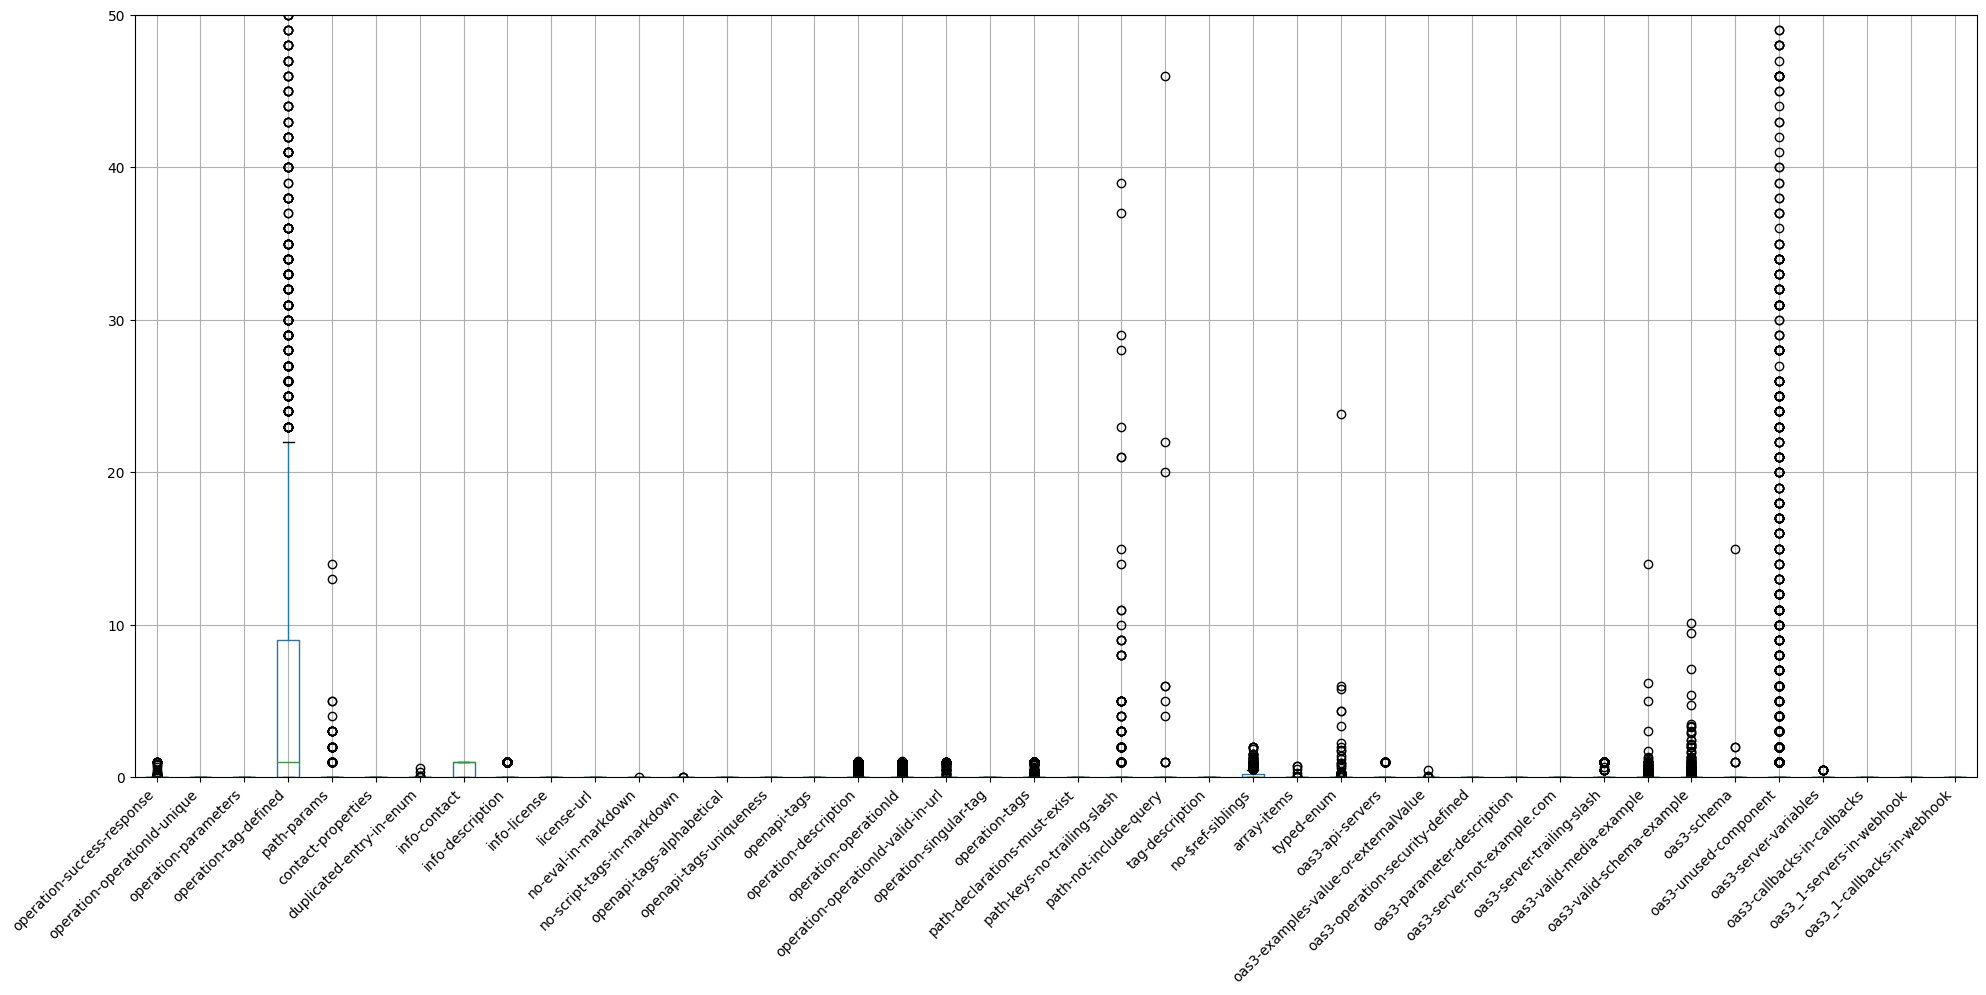

In [68]:
pd.DataFrame.boxplot(df_transformed, figsize=(20, 10))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.ylim(0,50)
plt.show()